In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
data = pd.read_csv("G:\\archive (1)\\framingham.csv")
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [19]:
data.shape

(4238, 16)

In [20]:
data.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [21]:
data.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [22]:
missing={}
for i in range(0,len(data.isnull().sum().index)):
    if data.isnull().sum()[i]!=0:
        missing[data.isnull().sum().index[i]]=data.isnull().sum()[i]
missing_data = pd.Series(missing).to_frame() #creating a data frame to be easy to manipulate with
missing_data=missing_data.rename(columns={0:'missing_value'}) # naming the column of th missing values
missing_data

,missing_value
education,105
cigsPerDay,29
BPMeds,53
totChol,50
BMI,19
heartRate,1
glucose,388


In [23]:
data.dropna(inplace =True)

In [26]:
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000
mean,0.443654,49.557440,1.979759,0.489059,9.022155,0.030361,0.005744,0.311543,0.027079,236.873085,132.368025,82.912062,25.784185,75.730580,81.856127,0.152352
std,0.496883,8.561133,1.022657,0.499949,11.918869,0.171602,0.075581,0.463187,0.162335,44.096223,22.092444,11.974825,4.065913,11.982952,23.910128,0.359411
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.250000,144.000000,90.000000,28.040000,82.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [27]:
data['TenYearCHD'].value_counts()

0    3099
1     557
Name: TenYearCHD, dtype: int64

In [28]:
correlation=data.corr()
correlation['TenYearCHD']

male               0.091745
age                0.233810
education         -0.063068
currentSmoker      0.019176
cigsPerDay         0.052159
BPMeds             0.089116
prevalentStroke    0.048351
prevalentHyp       0.181556
diabetes           0.093397
totChol            0.091127
sysBP              0.222885
diaBP              0.150342
BMI                0.081931
heartRate          0.020523
glucose            0.121942
TenYearCHD         1.000000
Name: TenYearCHD, dtype: float64

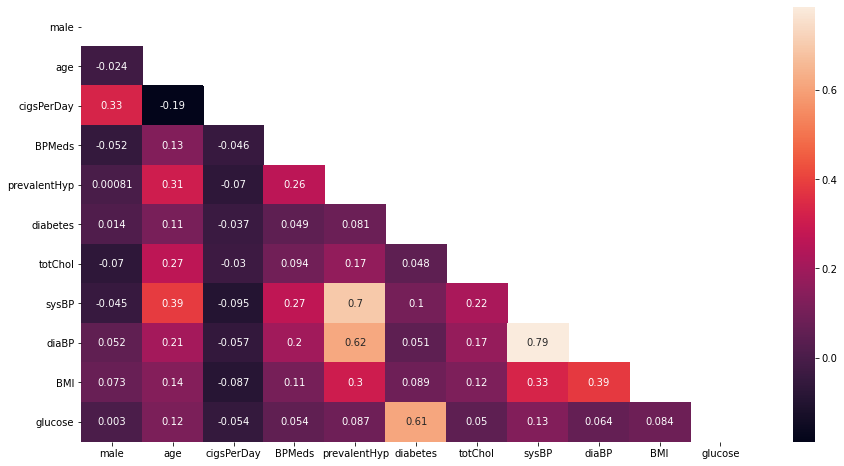

In [30]:
X=data.drop(['TenYearCHD','prevalentStroke','heartRate','currentSmoker','education'],axis=1)
y=data['TenYearCHD']
corr=X.corr()
plt.figure(figsize=(15,8))
mask=np.triu(np.ones_like(corr,dtype='bool'))
sns.heatmap(corr,mask=mask,annot=True)

In [31]:
X=X.drop(['sysBP'],axis=1)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=1111)

In [34]:
def evaluation(model,y_pred):
    train_score=model.score(X_train,y_train)
    test_score=model.score(X_test,y_test)
    print('the training score is {}'.format(round(train_score,2)))
    print('the test score is {}'.format(round(test_score,2)))
    print('_________________________________')
    from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score
    print('The confusion matrix is')
    print(confusion_matrix(y_test,y_pred))
    print('_________________________________')
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    accuracy=accuracy_score(y_test,y_pred)
    print('recall score is {}'.format(round(recall,2)))
    print('precision score is {}'.format(round(precision,2)))
    print('Accuracy score is {}'.format(round(accuracy,2)))

In [35]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
evaluation(lr,y_pred_lr)

the training score is 0.86
the test score is 0.85
_________________________________
The confusion matrix is
[[922   3]
 [165   7]]
_________________________________
recall score is 0.04
precision score is 0.7
Accuracy score is 0.85
